<a href="https://colab.research.google.com/github/melbinmv/Property-Data-Analysis/blob/main/Property-Data-Analysis-LandRegistry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import sqlite3
import requests
import os
import gc
import glob
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:

# Base API URL
BASE_URL = "https://data.gov.uk/api/action/"

def extract_year_from_url(url):
    """
    Extracts year from Land Registry URL
    Examples:
        pp-2017.csv          -> 2017
        pp-2017-part1.csv    -> 2017_part1
        pp-1995-part2.csv    -> 1995_part2
    """
    # Match year with optional part number
    # e.g pp-2017-part1.csv
    match_with_part = re.search(r'pp-(\d{4})-(part\d+)\.csv', url, re.IGNORECASE)

    # e.g pp-2017.csv
    match_year_only = re.search(r'pp-(\d{4})\.csv', url, re.IGNORECASE)

    if match_with_part:
        year = match_with_part.group(1)
        part = match_with_part.group(2)
        return f"{year}_{part}"

    elif match_year_only:
        year = match_year_only.group(1)
        return year

    else:
        # If no year found in URL return None
        return None


"""
Update package_search to avoid downloading
both full year AND part files for same year
"""

def package_search(query="price paid"):
    url    = f"{BASE_URL}package_search"
    params = {"q": query, "rows": 5}

    response = requests.get(url, params=params)
    response.raise_for_status()

    datasets             = response.json().get("result", {}).get("results", [])
    price_paid_resources = []
    seen_years           = set()   # ← Track which years already added

    for dataset in datasets:
        if "price paid" in dataset.get("title", "").lower() or \
           any("price paid" in tag.lower() for tag in dataset.get("tags", [])):

            resources = dataset.get("resources", [])

            for resource in resources:
                resource_url = resource.get("url")

                if resource_url and resource.get("format","").lower() == "csv":

                    year_label = extract_year_from_url(resource_url)
                    year       = re.search(r'(\d{4})', resource_url)
                    year_int   = int(year.group(1)) if year else None

                    is_part_file = "part" in resource_url.lower()

                    # Skip part file if full year already added
                    if year_int in seen_years and is_part_file:
                        print(f"⏭️  Skipping part file (full year exists): {resource_url}")
                        continue

                    # Skip part file if we prefer full year files
                    if not is_part_file and year_int:
                        seen_years.add(year_int)

                    price_paid_resources.append({
                        "url"       : resource_url,
                        "year_label": year_label
                    })

    return price_paid_resources


def download_csv(resource_url, save_path):
    """
    Downloads CSV from given URL and saves to save_path
    Skips download if file already exists
    """
    # Skip if already downloaded
    if os.path.exists(save_path):
        size_mb = os.path.getsize(save_path) / (1024**2)
        print(f"⏭️  Already exists: {save_path} ({size_mb:.1f} MB) - Skipping")
        return

    print(f"⬇️  Downloading: {resource_url}")

    try:
        response = requests.get(resource_url, stream=True, timeout=30)
        response.raise_for_status()

        downloaded = 0
        with open(save_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
                downloaded += len(chunk)

        size_mb = os.path.getsize(save_path) / (1024**2)
        print(f"✅ Saved: {save_path} | Size: {size_mb:.1f} MB")

    except Exception as e:
        print(f"❌ Failed: {save_path} | Error: {e}")
        # Remove incomplete file if download failed
        if os.path.exists(save_path):
            os.remove(save_path)


# ── Run ──────────────────────────────────────────────────

price_paid_resources = package_search()

if price_paid_resources:
    print(f"Found {len(price_paid_resources)} CSV resources\n")
    print("="*60)

    for resource in price_paid_resources:
        url        = resource["url"]
        year_label = resource["year_label"]

        # Build filename with year
        if year_label:
            save_path = f"price_paid_{year_label}.csv"
        else:
            # Fallback if year not found in URL
            save_path = f"price_paid_unknown_{price_paid_resources.index(resource)+1}.csv"

        download_csv(url, save_path)

    print("\n" + "="*60)
    print("DOWNLOAD SUMMARY")
    print("="*60)

    # Show all downloaded files
    downloaded_files = [
        f for f in os.listdir(".")
        if f.startswith("price_paid_") and f.endswith(".csv")
    ]
    downloaded_files.sort()

    total_size = 0
    for f in downloaded_files:
        size_mb    = os.path.getsize(f) / (1024**2)
        total_size += size_mb
        print(f"  📄 {f} | {size_mb:.1f} MB")

    print(f"\n  Total Files : {len(downloaded_files)}")
    print(f"  Total Size  : {total_size:.1f} MB")

else:
    print("❌ No Price Paid Datasets found.")

⏭️  Skipping part file (full year exists): http://prod.publicdata.landregistry.gov.uk.s3-website-eu-west-1.amazonaws.com/pp-1995-part1.csv
⏭️  Skipping part file (full year exists): http://prod.publicdata.landregistry.gov.uk.s3-website-eu-west-1.amazonaws.com/pp-1995-part2.csv
⏭️  Skipping part file (full year exists): http://prod.publicdata.landregistry.gov.uk.s3-website-eu-west-1.amazonaws.com/pp-1996-part1.csv
⏭️  Skipping part file (full year exists): http://prod.publicdata.landregistry.gov.uk.s3-website-eu-west-1.amazonaws.com/pp-1996-part2.csv
⏭️  Skipping part file (full year exists): http://prod.publicdata.landregistry.gov.uk.s3-website-eu-west-1.amazonaws.com/pp-1997-part1.csv
⏭️  Skipping part file (full year exists): http://prod.publicdata.landregistry.gov.uk.s3-website-eu-west-1.amazonaws.com/pp-1997-part2.csv
⏭️  Skipping part file (full year exists): http://prod.publicdata.landregistry.gov.uk.s3-website-eu-west-1.amazonaws.com/pp-1998-part1.csv
⏭️  Skipping part file (ful

In [4]:
def check_ram():
    """Shows current RAM usage - run before every major operation"""
    ram    = psutil.virtual_memory()
    used   = ram.used      / (1024**3)
    total  = ram.total     / (1024**3)
    free   = ram.available / (1024**3)
    pct    = ram.percent

    status = (
        "✅ OK"       if pct < 70 else
        "⚠️ WARNING"  if pct < 85 else
        "🔴 DANGER"
    )

    print(f"RAM Status : {status}")
    print(f"Used       : {used:.1f} GB / {total:.1f} GB")
    print(f"Free       : {free:.1f} GB")
    print(f"Usage      : {pct}%")

check_ram()

RAM Status : ✅ OK
Used       : 1.2 GB / 12.7 GB
Free       : 11.2 GB
Usage      : 11.6%


In [5]:
"""
First - peek inside each file to confirm which year it contains
"""

COLUMN_NAMES = [
    'TransactionId', 'Price', 'DateofTransfer', 'Postcode',
    'PropertyType', 'PropertyAge', 'Tenure', 'PAON', 'SAON',
    'Street', 'Locality', 'Town/City', 'District',
    'County', 'PPDCategory', 'Record_Status'
]

# Find all downloaded files with year-based names
csv_files = sorted(glob.glob("price_paid_*.csv"))
print(f"Files found: {len(csv_files)}")
print("="*60)

file_info = []
for file in csv_files:
    size_mb = os.path.getsize(file) / (1024**2)

    # Peek at first row to confirm year
    try:
        first_row = pd.read_csv(
            file,
            header=None,
            names=COLUMN_NAMES,
            nrows=1
        )
        year = pd.to_datetime(
            first_row["DateofTransfer"].iloc[0]
        ).year

    except Exception as e:
        year = "Unknown"

    file_info.append({
        "File"  : file,
        "Year"  : year,
        "SizeMB": round(size_mb, 1)
    })
    print(f"📄 {file} | Year: {year} | Size: {size_mb:.1f} MB")

file_df = pd.DataFrame(file_info).sort_values("Year")
print(f"\nTotal Size: {file_df['SizeMB'].sum():,.0f} MB")

Files found: 28
📄 price_paid_1995.csv | Year: 1995 | Size: 133.0 MB
📄 price_paid_1996.csv | Year: 1996 | Size: 161.8 MB
📄 price_paid_1997.csv | Year: 1997 | Size: 183.8 MB
📄 price_paid_1998.csv | Year: 1998 | Size: 176.7 MB
📄 price_paid_1999.csv | Year: 1999 | Size: 194.9 MB
📄 price_paid_2000.csv | Year: 2000 | Size: 184.4 MB
📄 price_paid_2001.csv | Year: 2001 | Size: 210.0 MB
📄 price_paid_2002.csv | Year: 2002 | Size: 228.2 MB
📄 price_paid_2003.csv | Year: 2003 | Size: 208.9 MB
📄 price_paid_2004.csv | Year: 2004 | Size: 208.5 MB
📄 price_paid_2005.csv | Year: 2005 | Size: 178.9 MB
📄 price_paid_2006.csv | Year: 2006 | Size: 224.3 MB
📄 price_paid_2007.csv | Year: 2007 | Size: 215.7 MB
📄 price_paid_2008.csv | Year: 2008 | Size: 110.3 MB
📄 price_paid_2009.csv | Year: 2009 | Size: 103.2 MB
📄 price_paid_2010.csv | Year: 2010 | Size: 109.2 MB
📄 price_paid_2011.csv | Year: 2011 | Size: 108.8 MB
📄 price_paid_2012.csv | Year: 2012 | Size: 110.1 MB
📄 price_paid_2013_part1.csv | Year: 2013 | Size:

In [6]:
"""
Pick 5 years that tell a strong market story:
1997 - Pre housing boom baseline
2003 - During housing boom
2008 - Financial crisis
2013 - Post crisis recovery
2017 - Most recent available
"""

KEEP_YEARS  = [1997, 2003, 2008, 2013, 2017]
SAMPLE_SIZE = 50000   # 50K rows per year = 250K total

def reduce_memory(df):
    """Optimise DataFrame memory usage"""
    before = df.memory_usage(deep=True).sum() / (1024**2)

    # Numeric
    df["Price"] = pd.to_numeric(
        df["Price"], errors="coerce"
    ).astype("float32")

    # Categories
    cat_cols = [
        "PropertyType", "PropertyAge", "Tenure",
        "PPDCategory",  "Record_Status", "County"
    ]
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype("category")

    after = df.memory_usage(deep=True).sum() / (1024**2)
    print(f"  💾 Memory: {before:.1f} MB → {after:.1f} MB "
          f"({((before-after)/before)*100:.0f}% reduction)")
    return df


# Load selected years one at a time
all_dataframes = []

for _, row in file_df[file_df["Year"].isin(KEEP_YEARS)].iterrows():

    file = row["File"]
    year = row["Year"]

    print(f"\nLoading {year} from {file}...")
    check_ram()

    try:
        year_chunks = []

        for chunk in pd.read_csv(
            file,
            header=None,
            names=COLUMN_NAMES,
            chunksize=10000,
            low_memory=False
        ):
            year_chunks.append(chunk)
            del chunk
            gc.collect()

        # Combine chunks
        year_df = pd.concat(year_chunks, ignore_index=True)
        del year_chunks
        gc.collect()

        # Sample to keep size manageable
        if len(year_df) > SAMPLE_SIZE:
            year_df = year_df.sample(n=SAMPLE_SIZE, random_state=42)

        # Tag source
        year_df["SourceYear"] = year
        year_df["SourceFile"] = file

        # Optimise memory
        year_df = reduce_memory(year_df)

        print(f"  ✅ {year}: {len(year_df):,} rows loaded")

        all_dataframes.append(year_df)
        del year_df
        gc.collect()

    except Exception as e:
        print(f"  ❌ Error loading {file}: {e}")

# Combine all years
print("\nCombining all years...")
data = pd.concat(all_dataframes, ignore_index=True)
del all_dataframes
gc.collect()

print(f"\n{'='*50}")
print(f"DATASET READY")
print(f"Total Records : {len(data):,}")
print(f"Years Covered : {sorted(data['SourceYear'].unique())}")
print(f"RAM Used      : {data.memory_usage(deep=True).sum() / (1024**2):.1f} MB")
print(f"{'='*50}")


Loading 1997 from price_paid_1997.csv...
RAM Status : ✅ OK
Used       : 1.2 GB / 12.7 GB
Free       : 11.2 GB
Usage      : 11.6%
  💾 Memory: 44.5 MB → 29.8 MB (33% reduction)
  ✅ 1997: 50,000 rows loaded

Loading 2003 from price_paid_2003.csv...
RAM Status : ✅ OK
Used       : 1.5 GB / 12.7 GB
Free       : 10.9 GB
Usage      : 14.4%
  💾 Memory: 44.6 MB → 29.9 MB (33% reduction)
  ✅ 2003: 50,000 rows loaded

Loading 2008 from price_paid_2008.csv...
RAM Status : ✅ OK
Used       : 1.6 GB / 12.7 GB
Free       : 10.8 GB
Usage      : 14.8%
  💾 Memory: 44.6 MB → 29.9 MB (33% reduction)
  ✅ 2008: 50,000 rows loaded

Loading 2013 from price_paid_2013_part1.csv...
RAM Status : ✅ OK
Used       : 1.6 GB / 12.7 GB
Free       : 10.8 GB
Usage      : 14.7%
  💾 Memory: 44.2 MB → 29.4 MB (33% reduction)
  ✅ 2013: 50,000 rows loaded

Loading 2013 from price_paid_2013_part2.csv...
RAM Status : ✅ OK
Used       : 1.6 GB / 12.7 GB
Free       : 10.8 GB
Usage      : 14.7%
  💾 Memory: 44.2 MB → 29.4 MB (33% red

In [7]:
data

,TransactionId,Price,DateofTransfer,Postcode,PropertyType,PropertyAge,Tenure,PAON,SAON,Street,Locality,Town/City,District,County,PPDCategory,Record_Status,SourceYear,SourceFile
0,{59752266-FBE7-4786-8902-3BC751B80A67},140000.0,1997-09-30 00:00,CM21 9ET,D,N,F,4,NaN,SPRINGHALL ROAD,SAWBRIDGEWORTH,SAWBRIDGEWORTH,EAST HERTFORDSHIRE,HERTFORDSHIRE,A,A,1997,price_paid_1997.csv
1,{32AC9B82-A5E8-4470-9FA8-B6CBD8C996E7},59995.0,1997-09-30 00:00,PE4 6QQ,S,N,F,45,NaN,AMBERLEY SLOPE,WERRINGTON,PETERBOROUGH,PETERBOROUGH,CAMBRIDGESHIRE,A,A,1997,price_paid_1997.csv
2,{9E195380-2D42-487F-BD6B-BC4A75AEF327},79000.0,1997-07-25 00:00,UB5 6YW,S,N,F,34,NaN,WHEATSHEAF CLOSE,NORTHOLT,NORTHOLT,HILLINGDON,GREATER LONDON,A,A,1997,price_paid_1997.csv
3,{8DDDD455-72E0-47D1-AE21-5789F6596F89},68000.0,1997-02-24 00:00,CR0 4EB,S,N,F,24,NaN,CROWLEY CRESCENT,CROYDON,CROYDON,CROYDON,GREATER LONDON,A,A,1997,price_paid_1997.csv
4,{F05D5998-D268-4479-8112-829E054B0C96},57550.0,1997-06-13 00:00,SW4 0HJ,F,N,L,39,NaN,NORTH STREET,LONDON,LONDON,LAMBETH,GREATER LONDON,A,A,1997,price_paid_1997.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349995,{64342BFE-935D-422C-E053-6C04A8C0FB8A},862500.0,2017-12-05 00:00,N7 9GY,F,Y,L,9A,FLAT 76,YORK WAY,NaN,LONDON,CAMDEN,GREATER LONDON,A,A,2017,price_paid_2017_part2.csv
349996,{5F54B81C-A85F-2B45-E053-6B04A8C01FB0},432000.0,2017-10-03 00:00,BA1 4LR,S,N,F,8,NaN,LANSDOWN LANE,NaN,BATH,BATH AND NORTH EAST SOMERSET,BATH AND NORTH EAST SOMERSET,A,A,2017,price_paid_2017_part2.csv
349997,{68FEB20B-C72A-38DA-E053-6C04A8C051AE},244950.0,2017-12-20 00:00,NR6 6SJ,S,Y,F,52,NaN,SILK MILL ROAD,NaN,NORWICH,BROADLAND,NORFOLK,A,A,2017,price_paid_2017_part2.csv
349998,{49B78529-DD5A-7921-E050-A8C063056E8D},220000.0,2017-01-27 00:00,DT9 3QE,T,N,F,8,NaN,GEORGE STREET,NaN,SHERBORNE,WEST DORSET,DORSET,A,A,2017,price_paid_2017_part2.csv


**Data Quality & KPI Validation**

In [8]:


def validate_data_quality(df):
    print("\nRunning Data Quality Checks...")
    print("="*50)

    quality_report = {
        "Total Records"          : len(df),
        "Null Prices"            : df["Price"].isnull().sum(),
        "Negative Prices"        : (df["Price"] < 0).sum(),
        "Zero Prices"            : (df["Price"] == 0).sum(),
        "Duplicate Transactions" : df["TransactionId"].duplicated().sum(),
        "Missing Postcodes"      : df["Postcode"].isnull().sum(),
        "Missing Streets"        : df["Street"].isnull().sum(),
        "Valid Postcode Format"  : df["Postcode"].str.match(
            r"^[A-Z]{1,2}[0-9][0-9A-Z]?\s[0-9][A-Z]{2}$",
            na=False
        ).sum()
    }

    report_df = pd.DataFrame(
        quality_report.items(),
        columns=["KPI", "Value"]
    )

    report_df["Status"] = report_df.apply(
        lambda row: "✅ PASS" if (
            row["KPI"] in [
                "Total Records",
                "Valid Postcode Format"
            ] and row["Value"] > 0
        ) or (
            row["KPI"] not in [
                "Total Records",
                "Valid Postcode Format"
            ] and row["Value"] == 0
        ) else "⚠️ CHECK",
        axis=1
    )

    print(report_df.to_string(index=False))
    report_df.to_csv("data_quality_report.csv", index=False)
    print("\n✅ Saved: data_quality_report.csv")
    return report_df

quality_report = validate_data_quality(data)


Running Data Quality Checks...
                   KPI  Value   Status
         Total Records 350000   ✅ PASS
           Null Prices      0   ✅ PASS
       Negative Prices      0   ✅ PASS
           Zero Prices      0   ✅ PASS
Duplicate Transactions      0   ✅ PASS
     Missing Postcodes    708 ⚠️ CHECK
       Missing Streets   5720 ⚠️ CHECK
 Valid Postcode Format 349292   ✅ PASS

✅ Saved: data_quality_report.csv


# **Transform**

In [9]:
# More information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350000 entries, 0 to 349999
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   TransactionId   350000 non-null  object  
 1   Price           350000 non-null  float32 
 2   DateofTransfer  350000 non-null  object  
 3   Postcode        349292 non-null  object  
 4   PropertyType    350000 non-null  object  
 5   PropertyAge     350000 non-null  category
 6   Tenure          350000 non-null  object  
 7   PAON            349700 non-null  object  
 8   SAON            44320 non-null   object  
 9   Street          344280 non-null  object  
 10  Locality        218598 non-null  object  
 11  Town/City       350000 non-null  object  
 12  District        350000 non-null  object  
 13  County          350000 non-null  object  
 14  PPDCategory     350000 non-null  object  
 15  Record_Status   350000 non-null  category
 16  SourceYear      350000 non-null  int64

In [10]:
# Checking for null values
data.isnull().sum()

,0
TransactionId,0
Price,0
DateofTransfer,0
Postcode,708
PropertyType,0
PropertyAge,0
Tenure,0
PAON,300
SAON,305680
Street,5720


**Data Type Optimisation**

In [11]:
print("BEFORE OPTIMISATION")
print("="*50)
print(f"Memory Usage: {data.memory_usage(deep=True).sum() / (1024**2):.1f} MB")
print(data.dtypes)

# ── Step 1 - Convert Date ──────────────────────────────

data["DateofTransfer"] = pd.to_datetime(
    data["DateofTransfer"],
    errors="coerce"         # Converts bad dates to NaT instead of crashing
)
print("\n✅ DateofTransfer → datetime64")

# ── Step 2 - Downcast Numeric ──────────────────────────

# Price - float64 to float32
data["Price"] = data["Price"].astype("float32")
print("✅ Price → float32")

# SourceYear - int64 to int16
data["SourceYear"] = data["SourceYear"].astype("int16")
print("✅ SourceYear → int16")

# ── Step 3 - Convert Low Cardinality to Category ───────

# Check unique values first
cat_candidates = [
    "PropertyType",
    "PropertyAge",
    "Tenure",
    "PPDCategory",
    "Record_Status",
    "County"
]

print("\nUnique Value Counts (before category conversion):")
for col in cat_candidates:
    unique_count = data[col].nunique()
    print(f"  {col:<20}: {unique_count:>6,} unique values")

# Convert to category
for col in cat_candidates:
    data[col] = data[col].astype("category")
    print(f"✅ {col} → category")

# ── Step 4 - Check Results ─────────────────────────────

print("\n" + "="*50)
print("AFTER OPTIMISATION")
print("="*50)
print(data.dtypes)

# Memory comparison
after_memory = data.memory_usage(deep=True).sum() / (1024**2)
print(f"\nMemory Before : 89.3 MB")
print(f"Memory After  : {after_memory:.1f} MB")
print(f"Memory Saved  : {89.3 - after_memory:.1f} MB")
print(f"Reduction     : {((89.3 - after_memory) / 89.3) * 100:.1f}%")

BEFORE OPTIMISATION
Memory Usage: 273.7 MB
TransactionId       object
Price              float32
DateofTransfer      object
Postcode            object
PropertyType        object
PropertyAge       category
Tenure              object
PAON                object
SAON                object
Street              object
Locality            object
Town/City           object
District            object
County              object
PPDCategory         object
Record_Status     category
SourceYear           int64
SourceFile          object
dtype: object

✅ DateofTransfer → datetime64
✅ Price → float32
✅ SourceYear → int16

Unique Value Counts (before category conversion):
  PropertyType        :      5 unique values
  PropertyAge         :      2 unique values
  Tenure              :      3 unique values
  PPDCategory         :      2 unique values
  Record_Status       :      1 unique values
  County              :    123 unique values
✅ PropertyType → category
✅ PropertyAge → category
✅ Tenure → cate

In [12]:
# Drop all the Postcodes with null values
data.dropna(subset=["Postcode"], inplace=True)
# Checking for Null Values again
data.isnull().sum()

,0
TransactionId,0
Price,0
DateofTransfer,0
Postcode,0
PropertyType,0
PropertyAge,0
Tenure,0
PAON,300
SAON,305233
Street,5579


In [13]:
# Delete column district
data.drop(columns=["District"], inplace=True)
# Show the names of columns of dataset
data.columns

Index(['TransactionId', 'Price', 'DateofTransfer', 'Postcode', 'PropertyType',
       'PropertyAge', 'Tenure', 'PAON', 'SAON', 'Street', 'Locality',
       'Town/City', 'County', 'PPDCategory', 'Record_Status', 'SourceYear',
       'SourceFile'],
      dtype='object')

In [14]:
def standardize_address(row):
    components = [
        str(row.get("PAON",      "N/A")) if pd.notna(row.get("PAON"))      else "N/A",
        str(row.get("SAON",      "N/A")) if pd.notna(row.get("SAON"))      else "N/A",
        str(row.get("Street",    "N/A")) if pd.notna(row.get("Street"))    else "N/A",
        str(row.get("Locality",  "N/A")) if pd.notna(row.get("Locality"))  else "N/A",
        str(row.get("Town/City", "N/A")) if pd.notna(row.get("Town/City")) else "N/A",
        str(row.get("County",    "N/A")) if pd.notna(row.get("County"))    else "N/A",
        str(row.get("Postcode",  "N/A")) if pd.notna(row.get("Postcode"))  else "N/A"
    ]
    address = ", ".join(components)
    address = address.title()
    address = re.sub(r"\s{2,}", " ", address).strip()
    return address

print("Standardizing addresses...")
data["StandardizedAddress"] = data.apply(standardize_address, axis=1)
print(f"✅ Done | Records: {len(data):,}")
check_ram()

Standardizing addresses...
✅ Done | Records: 349,292
RAM Status : ✅ OK
Used       : 1.6 GB / 12.7 GB
Free       : 10.8 GB
Usage      : 15.0%


In [15]:
print("DUPLICATE INVESTIGATION")
print("="*60)

# ── Check 1 - How many fully identical rows ────────────────
full_duplicates = data.duplicated().sum()
print(f"\nFully identical rows     : {full_duplicates:,}")

# ── Check 2 - How many duplicate TransactionIds ───────────
id_duplicates = data.duplicated(subset=["TransactionId"]).sum()
print(f"Duplicate TransactionIds : {id_duplicates:,}")

# ── Check 3 - Show example duplicates ─────────────────────
print("\nExample Duplicate Rows:")
duplicate_ids = data[
    data.duplicated(subset=["TransactionId"], keep=False)
]["TransactionId"].unique()[:3]   # Look at first 3 duplicate IDs

for tid in duplicate_ids:
    print(f"\nTransactionId: {tid}")
    print(
        data[data["TransactionId"] == tid][
            ["TransactionId","Price","DateofTransfer",
             "PropertyType","Record_Status","SourceYear"]
        ].to_string(index=False)
    )

DUPLICATE INVESTIGATION

Fully identical rows     : 0
Duplicate TransactionIds : 0

Example Duplicate Rows:


In [16]:
# Check duplicates
remaining_dupes = data.duplicated(subset=["TransactionId"]).sum()
full_dupes      = data.duplicated().sum()

print(f"Fully identical rows     : {full_dupes:,}")
print(f"Duplicate TransactionIds : {remaining_dupes:,}")

if remaining_dupes == 0:
    print("\n✅ All duplicates resolved")
else:
    print(f"\n⚠️ {remaining_dupes:,} still remain")
    # Force remove any remaining
    data = data.drop_duplicates(
        subset=["TransactionId"],
        keep="first"
    )
    print(f"✅ Force removed remaining duplicates")

# Final summary
print("\nFINAL DATASET SUMMARY")
print("="*60)
print(f"Total Records  : {len(data):,}")
print(f"\nRecords by Year:")
print(
    data.groupby("SourceYear")
    .size()
    .reset_index(name="Count")
    .to_string(index=False)
)
print(f"\nSource Files Kept:")
for f in sorted(data["SourceFile"].unique()):
    count = len(data[data["SourceFile"] == f])
    print(f"  ✅ {f} | {count:,} records")

POST-FIX VERIFICATION
Fully identical rows     : 0
Duplicate TransactionIds : 0

✅ All duplicates resolved

FINAL DATASET SUMMARY
Total Records  : 349,292

Records by Year:
 SourceYear  Count
       1997  49965
       2003  49959
       2008  49961
       2013  99948
       2017  99459

Source Files Kept:
  ✅ price_paid_1997.csv | 49,965 records
  ✅ price_paid_2003.csv | 49,959 records
  ✅ price_paid_2008.csv | 49,961 records
  ✅ price_paid_2013_part1.csv | 49,989 records
  ✅ price_paid_2013_part2.csv | 49,959 records
  ✅ price_paid_2017_part1.csv | 49,757 records
  ✅ price_paid_2017_part2.csv | 49,702 records


**NumPy Statistical Analysis**

In [17]:
print("="*50)
print("STATISTICAL ANALYSIS")
print("="*50)

data["Price"] = pd.to_numeric(data["Price"], errors="coerce")

# Basic stats
print(f"\nMean Price   : £{np.mean(data['Price']):>12,.2f}")
print(f"Median Price : £{np.median(data['Price']):>12,.2f}")
print(f"Std Dev      : £{np.std(data['Price']):>12,.2f}")
print(f"Min Price    : £{np.min(data['Price']):>12,.2f}")
print(f"Max Price    : £{np.max(data['Price']):>12,.2f}")

# Percentiles
p = np.percentile(data["Price"].dropna(), [25, 50, 75, 90, 95])
print(f"\n25th Pct : £{p[0]:>12,.2f}")
print(f"50th Pct : £{p[1]:>12,.2f}")
print(f"75th Pct : £{p[2]:>12,.2f}")
print(f"90th Pct : £{p[3]:>12,.2f}")
print(f"95th Pct : £{p[4]:>12,.2f}")

# Stats by year
print("\nAverage Price By Year:")
year_stats = (
    data.groupby("SourceYear")["Price"]
    .agg(["mean", "median", "count"])
    .reset_index()
)
year_stats.columns = ["Year", "AvgPrice", "MedianPrice", "Count"]
print(year_stats.to_string(index=False))

# Log price + Z-Score
data["LogPrice"]    = np.log(data["Price"].clip(lower=1))
data["PriceZScore"] = (
    (data["Price"] - np.mean(data["Price"])) /
     np.std(data["Price"])
)

# Flag outliers
data["IsOutlier"] = np.where(
    np.abs(data["PriceZScore"]) > 3, True, False
)

outlier_count = data["IsOutlier"].sum()
print(f"\nOutliers Detected : {outlier_count:,}")
print(f"Outlier Percentage: {(outlier_count/len(data))*100:.2f}%")

# Remove outliers
data_clean = data[data["IsOutlier"] == False].copy()
print(f"Records After Cleaning: {len(data_clean):,}")

gc.collect()

STATISTICAL ANALYSIS

Mean Price   : £  237,374.98
Median Price : £  162,000.00
Std Dev      : £1,163,964.88
Min Price    : £      100.00
Max Price    : £300,000,000.00

25th Pct : £   98,000.00
50th Pct : £  162,000.00
75th Pct : £  255,000.00
90th Pct : £  412,000.00
95th Pct : £  565,000.00

Average Price By Year:
 Year      AvgPrice  MedianPrice  Count
 1997  79003.851562      60000.0  49965
 2003 156908.046875     130000.0  49959
 2008 215448.484375     170000.0  49961
 2013 254292.015625     184000.0  99948
 2017 351368.750000     225000.0  99459

Outliers Detected : 614
Outlier Percentage: 0.18%
Records After Cleaning: 348,678


13

In [20]:
"""
Recommendation:
Use Business Logic method for property prices
It is the most explainable and domain-appropriate
"""

before = len(data)

# Remove clear data errors (below £5K)
data_clean = data[data["Price"] >= 5_000].copy()

# Flag ultra luxury but keep them
data_clean["IsUltraLuxury"] = data_clean["Price"] > 10_000_000

# Remove only genuine errors
data_clean = data_clean[data_clean["Price"] <= 300_000_000].copy()

after = len(data_clean)

print(f"Records before     : {before:,}")
print(f"Records removed    : {before - after:,}")
print(f"Records remaining  : {after:,}")
print(f"Ultra luxury kept  : {data_clean['IsUltraLuxury'].sum():,}")

# Recalculate stats on clean data
print("\nREVISED STATISTICS")
print("="*60)
print(f"Mean Price   : £{data_clean['Price'].mean():>12,.2f}")
print(f"Median Price : £{data_clean['Price'].median():>12,.2f}")
print(f"Std Dev      : £{data_clean['Price'].std():>12,.2f}")
print(f"Min Price    : £{data_clean['Price'].min():>12,.2f}")
print(f"Max Price    : £{data_clean['Price'].max():>12,.2f}")

print("\nAverage Price by Year (Clean Data):")
print(
    data_clean.groupby("SourceYear")["Price"]
    .agg(
        AvgPrice   = "mean",
        MedianPrice= "median",
        Count      = "count"
    )
    .reset_index()
    .to_string(index=False)
)

Records before     : 349,292
Records removed    : 286
Records remaining  : 349,006
Ultra luxury kept  : 169

REVISED STATISTICS
Mean Price   : £  237,567.81
Median Price : £  162,000.00
Std Dev      : £1,164,425.25
Min Price    : £    5,000.00
Max Price    : £300,000,000.00

Average Price by Year (Clean Data):
 SourceYear      AvgPrice  MedianPrice  Count
       1997  79056.125000      60000.0  49931
       2003 156911.171875     130000.0  49958
       2008 215457.031250     170000.0  49959
       2013 254299.578125     184000.0  99945
       2017 352234.812500     225000.0  99213


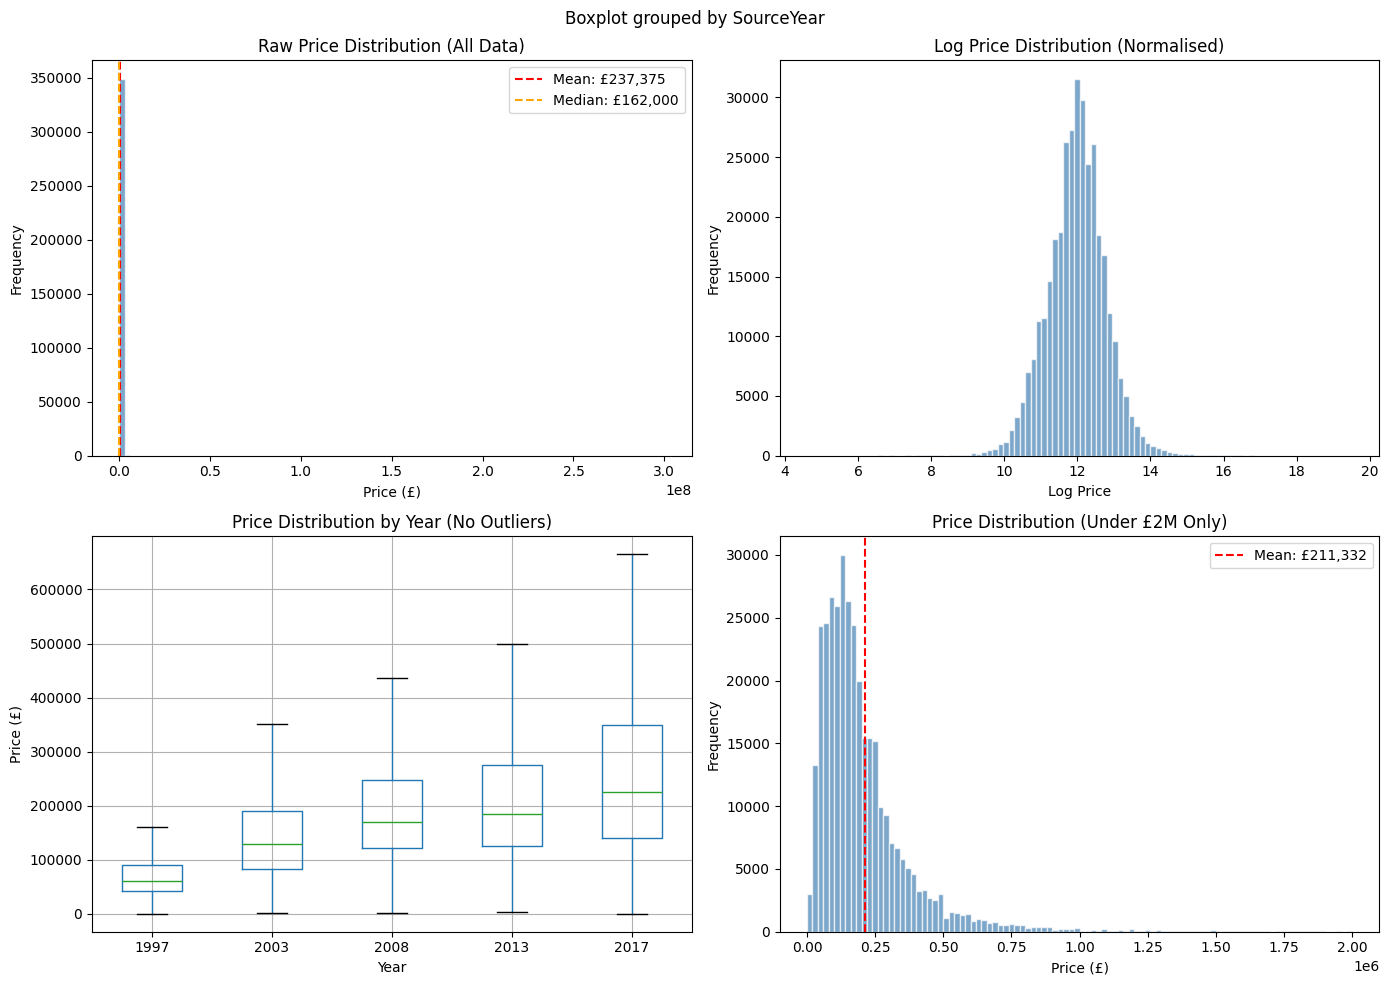

In [21]:
"""Understand your price distribution"""

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Property Price Distribution Analysis", fontsize=14)

# ── Plot 1 - Raw price distribution ───────────────────────
axes[0,0].hist(
    data["Price"].dropna(),
    bins=100,
    color="steelblue",
    alpha=0.7,
    edgecolor="white"
)
axes[0,0].set_title("Raw Price Distribution (All Data)")
axes[0,0].set_xlabel("Price (£)")
axes[0,0].set_ylabel("Frequency")
axes[0,0].axvline(
    data["Price"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: £{data['Price'].mean():,.0f}"
)
axes[0,0].axvline(
    data["Price"].median(),
    color="orange",
    linestyle="--",
    label=f"Median: £{data['Price'].median():,.0f}"
)
axes[0,0].legend()

# ── Plot 2 - Log price distribution ───────────────────────
axes[0,1].hist(
    np.log(data["Price"].dropna()),
    bins=100,
    color="steelblue",
    alpha=0.7,
    edgecolor="white"
)
axes[0,1].set_title("Log Price Distribution (Normalised)")
axes[0,1].set_xlabel("Log Price")
axes[0,1].set_ylabel("Frequency")

# ── Plot 3 - Price by year boxplot ────────────────────────
data.boxplot(
    column="Price",
    by="SourceYear",
    ax=axes[1,0],
    showfliers=False    # Hide outliers for cleaner view
)
axes[1,0].set_title("Price Distribution by Year (No Outliers)")
axes[1,0].set_xlabel("Year")
axes[1,0].set_ylabel("Price (£)")

# ── Plot 4 - Prices under £2M only ────────────────────────
normal_prices = data[data["Price"] <= 2_000_000]["Price"]
axes[1,1].hist(
    normal_prices,
    bins=100,
    color="steelblue",
    alpha=0.7,
    edgecolor="white"
)
axes[1,1].set_title("Price Distribution (Under £2M Only)")
axes[1,1].set_xlabel("Price (£)")
axes[1,1].set_ylabel("Frequency")
axes[1,1].axvline(
    normal_prices.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: £{normal_prices.mean():,.0f}"
)
axes[1,1].legend()

plt.tight_layout()
plt.savefig("price_distribution_analysis.png")
plt.show()

# Load

**Build Dimension Tables**


In [22]:

# Date Dimension
date_dim = data_clean[["TransactionId", "DateofTransfer"]].copy()
date_dim["DateofTransfer"] = pd.to_datetime(date_dim["DateofTransfer"])
date_dim["Day"]     = date_dim["DateofTransfer"].dt.day
date_dim["Month"]   = date_dim["DateofTransfer"].dt.month
date_dim["Year"]    = date_dim["DateofTransfer"].dt.year
date_dim["Quarter"] = date_dim["DateofTransfer"].dt.quarter
date_dim["DateId"]  = date_dim.index + 1
print(f"✅ Date Dimension      : {len(date_dim):,} rows")

# Property Type Dimension
property_type_dim = data_clean[[
    "TransactionId", "PropertyType",
    "PropertyAge",   "Tenure"
]].copy()
property_type_dim["PropertyTypeId"] = property_type_dim.index + 1
print(f"✅ Property Dimension  : {len(property_type_dim):,} rows")

# Address Dimension
address_dim  = data_clean[["TransactionId", "StandardizedAddress"]].copy()
split_address = (
    address_dim["StandardizedAddress"]
    .str.split(", ", expand=True, n=6)
)
split_address.columns = [
    "PAON", "SAON", "Street",
    "Locality", "Town_City", "County", "Postcode"
]
address_dim  = pd.concat(
    [address_dim["TransactionId"], split_address], axis=1
)
address_dim["AddressId"] = address_dim.index + 1
print(f"✅ Address Dimension   : {len(address_dim):,} rows")

# PPD Category Dimension
ppd_category_dim = data_clean[["TransactionId", "PPDCategory"]].copy()
ppd_category_dim["PPDCategoryId"] = ppd_category_dim.index + 1
print(f"✅ PPD Category Dim    : {len(ppd_category_dim):,} rows")

# Fact Table
fact_table = data_clean[["TransactionId", "Price"]].copy()

fact_table_final = (
    fact_table
    .merge(address_dim[["TransactionId", "AddressId"]],       on="TransactionId", how="inner")
    .merge(date_dim[["TransactionId", "DateId"]],             on="TransactionId", how="inner")
    .merge(property_type_dim[["TransactionId","PropertyTypeId"]], on="TransactionId", how="inner")
    .merge(ppd_category_dim[["TransactionId","PPDCategoryId"]], on="TransactionId", how="inner")
)
fact_table_final = fact_table_final[[
    "TransactionId", "Price", "DateId",
    "PropertyTypeId", "AddressId", "PPDCategoryId"
]]
print(f"✅ Fact Table          : {len(fact_table_final):,} rows")
gc.collect()

✅ Date Dimension      : 349,006 rows
✅ Property Dimension  : 349,006 rows
✅ Address Dimension   : 349,006 rows
✅ PPD Category Dim    : 349,006 rows
✅ Fact Table          : 349,006 rows


20

**Regression Analysis**

REGRESSION ANALYSIS

Training Samples  : 279,204
Testing Samples   : 69,802
R² Score          : 0.3541
RMSE (log scale)  : 0.6437
RMSE (£)          : £1,332,493.64

Feature Coefficients:
  PropertyTypeEncoded      : -0.1592
  TenureEncoded            : -0.3232
  PropertyAgeEncoded       : 0.1136
  YearEncoded              : 0.0575


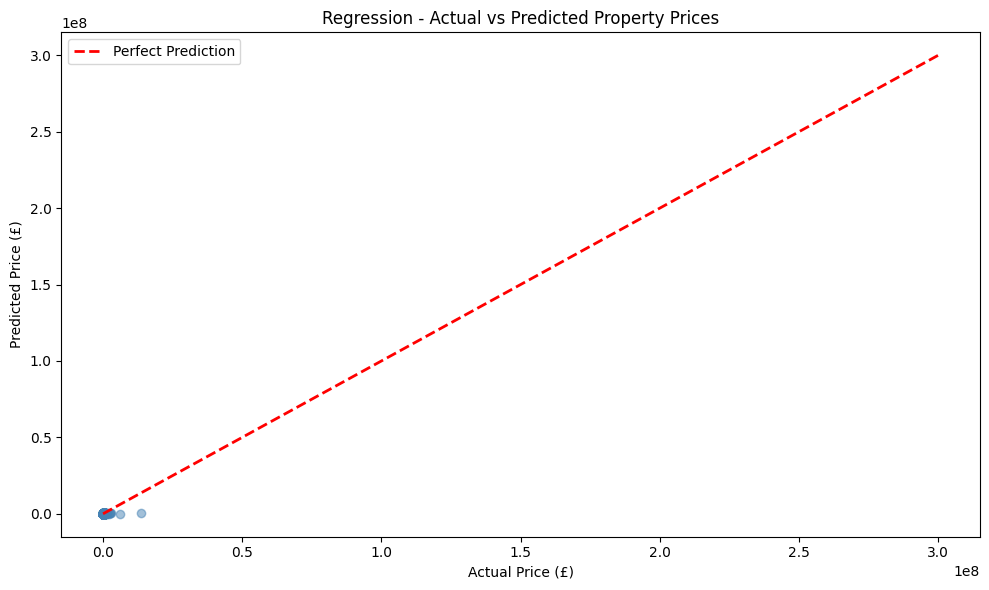

✅ Saved: regression_actual_vs_predicted.png
✅ Saved: regression_results.csv


3602

In [24]:
"""**Regression Analysis**"""

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("="*60)
print("REGRESSION ANALYSIS")
print("="*60)

# ── Encode categorical variables ───────────────────────────
le         = LabelEncoder()
reg_data   = data_clean.copy()

reg_data["PropertyTypeEncoded"] = le.fit_transform(
    reg_data["PropertyType"].astype(str)
)
reg_data["TenureEncoded"] = le.fit_transform(
    reg_data["Tenure"].astype(str)
)
reg_data["PropertyAgeEncoded"] = le.fit_transform(
    reg_data["PropertyAge"].astype(str)
)
reg_data["YearEncoded"] = reg_data["SourceYear"].astype(int)

# ── Use Log Price as target (better for skewed data) ───────
reg_data["LogPrice"] = np.log(reg_data["Price"])

features = [
    "PropertyTypeEncoded",
    "TenureEncoded",
    "PropertyAgeEncoded",
    "YearEncoded"
]

X = reg_data[features].values
y = reg_data["LogPrice"].values      # Log price target

# ── Split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ── Train ──────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

# ── Evaluate ───────────────────────────────────────────────
y_pred      = model.predict(X_test)
r2          = r2_score(y_test, y_pred)
rmse        = np.sqrt(mean_squared_error(y_test, y_pred))

# Convert back from log to £
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(y_pred)
rmse_actual   = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print(f"\nTraining Samples  : {len(X_train):,}")
print(f"Testing Samples   : {len(X_test):,}")
print(f"R² Score          : {r2:.4f}")
print(f"RMSE (log scale)  : {rmse:.4f}")
print(f"RMSE (£)          : £{rmse_actual:,.2f}")

print("\nFeature Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat:<25}: {coef:.4f}")

# ── Plot ───────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.scatter(
    y_test_actual[:500],
    y_pred_actual[:500],
    alpha=0.5,
    color="steelblue"
)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)
plt.xlabel("Actual Price (£)")
plt.ylabel("Predicted Price (£)")
plt.title("Regression - Actual vs Predicted Property Prices")
plt.legend()
plt.tight_layout()
plt.savefig("regression_actual_vs_predicted.png")
plt.show()
print("✅ Saved: regression_actual_vs_predicted.png")

# ── Save results ───────────────────────────────────────────
regression_results = pd.DataFrame({
    "ActualPrice"    : y_test_actual,
    "PredictedPrice" : y_pred_actual,
    "Residual"       : y_test_actual - y_pred_actual
})
regression_results.to_csv("regression_results.csv", index=False)
print("✅ Saved: regression_results.csv")

del reg_data
gc.collect()

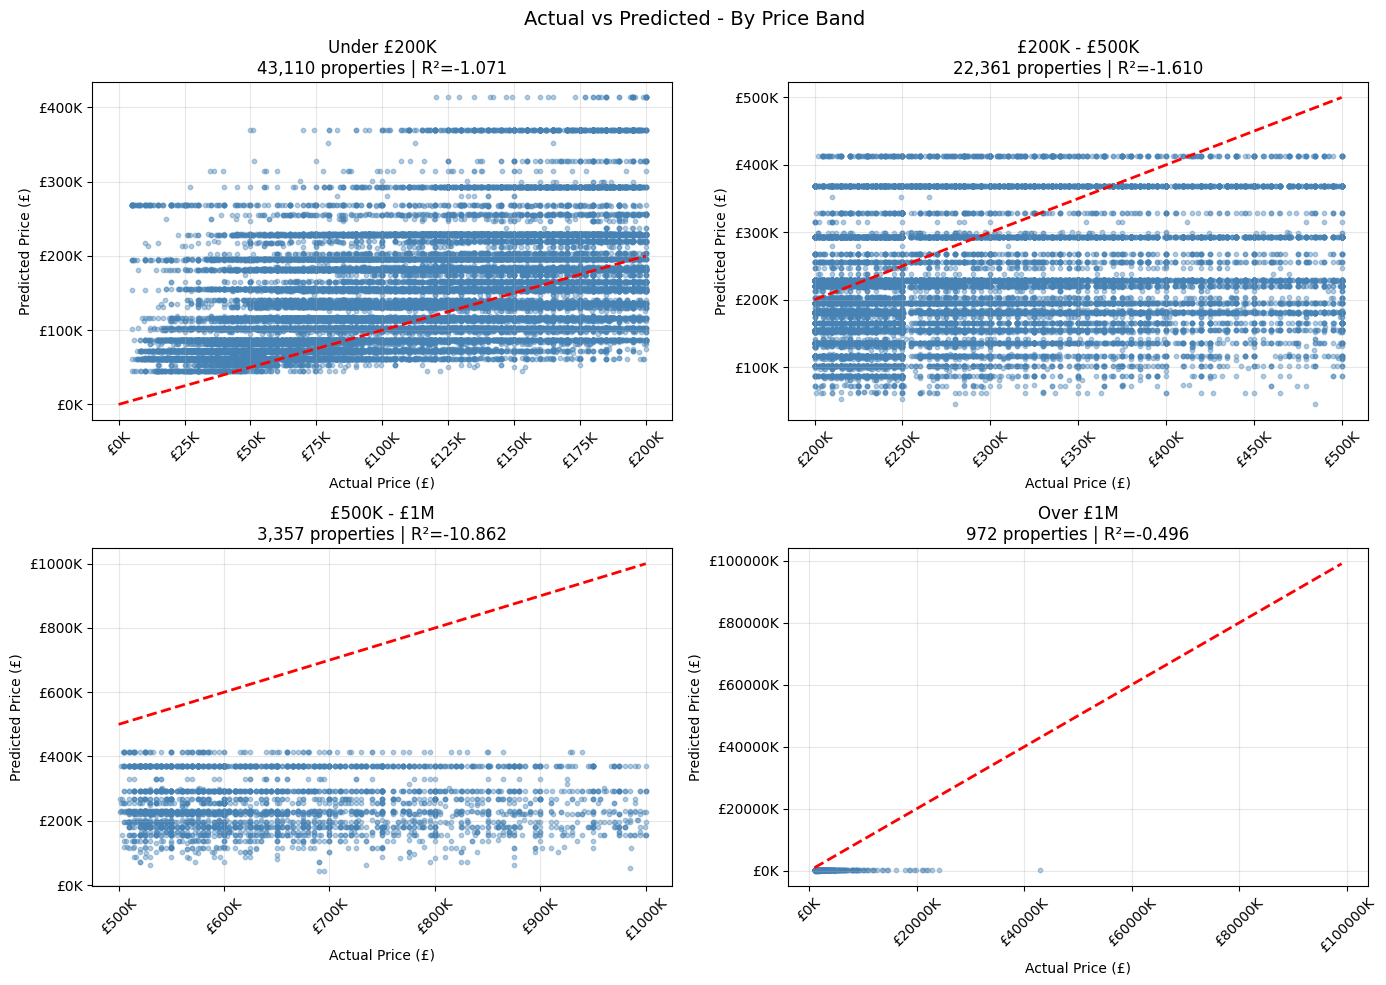

✅ Saved: regression_by_price_band.png


In [26]:
import matplotlib.ticker as mticker

"""
Show separate plots for different price bands
Tells a much richer story
"""

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Actual vs Predicted - By Price Band", fontsize=14)

price_bands = [
    ("Under £200K",      0,        200_000),
    ("£200K - £500K",    200_000,  500_000),
    ("£500K - £1M",      500_000,  1_000_000),
    ("Over £1M",         1_000_000, 99_000_000)
]

for ax, (label, low, high) in zip(axes.flatten(), price_bands):

    mask = (y_test_actual >= low) & (y_test_actual < high)

    if mask.sum() == 0:
        ax.set_title(f"{label}\nNo data")
        continue

    ax.scatter(
        y_test_actual[mask],
        y_pred_actual[mask],
        alpha=0.4,
        color="steelblue",
        s=10
    )
    ax.plot(
        [low, high],
        [low, high],
        "r--",
        linewidth=2
    )

    # R² for this band
    from sklearn.metrics import r2_score
    if mask.sum() > 2:
        band_r2 = r2_score(
            y_test_actual[mask],
            y_pred_actual[mask]
        )
        ax.set_title(f"{label}\n{mask.sum():,} properties | R²={band_r2:.3f}")
    else:
        ax.set_title(f"{label}\n{mask.sum():,} properties")

    ax.set_xlabel("Actual Price (£)")
    ax.set_ylabel("Predicted Price (£)")

    # Format axis
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, p: f"£{x/1000:.0f}K")
    )
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, p: f"£{x/1000:.0f}K")
    )
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("regression_by_price_band.png")
plt.show()
print("✅ Saved: regression_by_price_band.png")

**Time Series Analysis & Forecasting**

TIME SERIES ANALYSIS

6-Month Price Forecast:
  Month +1: £369,036.54
  Month +2: £374,237.05
  Month +3: £379,437.56
  Month +4: £384,638.07
  Month +5: £389,838.58
  Month +6: £395,039.09


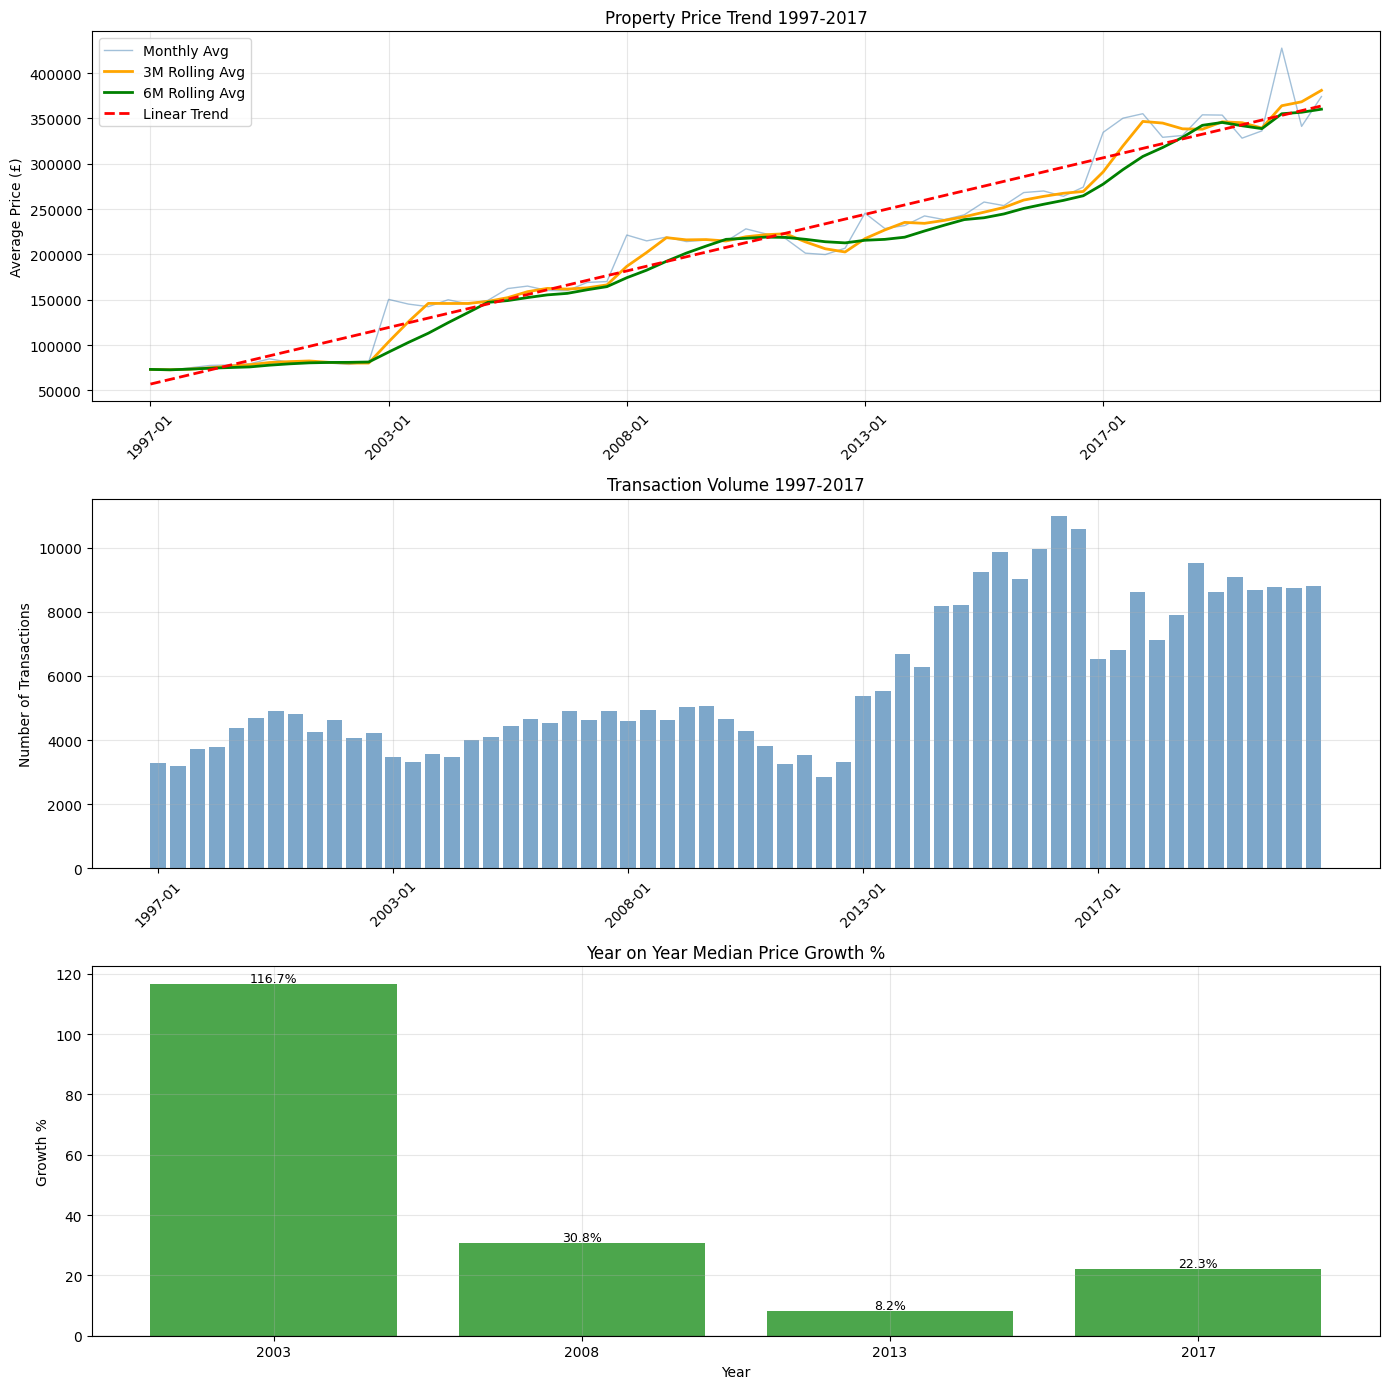

✅ Saved: time_series_analysis.png
✅ Saved: monthly_price_trends.csv


In [27]:
print("="*60)
print("TIME SERIES ANALYSIS")
print("="*60)

# ── Prepare monthly data ───────────────────────────────────
data_clean["DateofTransfer"] = pd.to_datetime(
    data_clean["DateofTransfer"]
)
data_clean["YearMonth"] = (
    data_clean["DateofTransfer"].dt.to_period("M")
)

monthly_prices = (
    data_clean
    .groupby("YearMonth")["Price"]
    .agg(
        AvgPrice         = "mean",
        MedianPrice      = "median",
        TransactionCount = "count"
    )
    .reset_index()
)
monthly_prices["YearMonth"] = monthly_prices["YearMonth"].astype(str)

# ── Rolling averages ───────────────────────────────────────
monthly_prices["RollingAvg_3M"] = (
    monthly_prices["AvgPrice"]
    .rolling(window=3, min_periods=1)
    .mean()
)
monthly_prices["RollingAvg_6M"] = (
    monthly_prices["AvgPrice"]
    .rolling(window=6, min_periods=1)
    .mean()
)

# ── Linear trend + forecast ────────────────────────────────
x            = np.arange(len(monthly_prices))
y            = monthly_prices["AvgPrice"].values
coefficients = np.polyfit(x, y, deg=1)
trend_line   = np.polyval(coefficients, x)
monthly_prices["LinearTrend"] = trend_line

# Forecast next 6 months
future_x      = np.arange(
    len(monthly_prices),
    len(monthly_prices) + 6
)
future_prices = np.polyval(coefficients, future_x)

print("\n6-Month Price Forecast:")
for i, price in enumerate(future_prices, start=1):
    print(f"  Month +{i}: £{price:,.2f}")

# ── Plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Plot 1 - Price trend
tick_positions = range(0, len(monthly_prices), 12)
tick_labels    = [
    monthly_prices["YearMonth"].iloc[i]
    for i in tick_positions
]

axes[0].plot(
    monthly_prices["YearMonth"],
    monthly_prices["AvgPrice"],
    label="Monthly Avg",
    color="steelblue",
    alpha=0.5,
    linewidth=1
)
axes[0].plot(
    monthly_prices["YearMonth"],
    monthly_prices["RollingAvg_3M"],
    label="3M Rolling Avg",
    color="orange",
    linewidth=2
)
axes[0].plot(
    monthly_prices["YearMonth"],
    monthly_prices["RollingAvg_6M"],
    label="6M Rolling Avg",
    color="green",
    linewidth=2
)
axes[0].plot(
    monthly_prices["YearMonth"],
    monthly_prices["LinearTrend"],
    label="Linear Trend",
    color="red",
    linestyle="--",
    linewidth=2
)
axes[0].set_title("Property Price Trend 1997-2017")
axes[0].set_ylabel("Average Price (£)")
axes[0].set_xticks(list(tick_positions))
axes[0].set_xticklabels(tick_labels, rotation=45)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 - Transaction volume
axes[1].bar(
    monthly_prices["YearMonth"],
    monthly_prices["TransactionCount"],
    color="steelblue",
    alpha=0.7
)
axes[1].set_title("Transaction Volume 1997-2017")
axes[1].set_ylabel("Number of Transactions")
axes[1].set_xticks(list(tick_positions))
axes[1].set_xticklabels(tick_labels, rotation=45)
axes[1].grid(alpha=0.3)

# Plot 3 - Year on year growth
yearly_avg = (
    data_clean.groupby("SourceYear")["Price"]
    .median()
    .reset_index()
)
yearly_avg["GrowthPct"] = yearly_avg["Price"].pct_change() * 100

axes[2].bar(
    yearly_avg["SourceYear"].astype(str),
    yearly_avg["GrowthPct"],
    color=[
        "green" if x > 0 else "red"
        for x in yearly_avg["GrowthPct"].fillna(0)
    ],
    alpha=0.7
)
axes[2].set_title("Year on Year Median Price Growth %")
axes[2].set_ylabel("Growth %")
axes[2].set_xlabel("Year")
axes[2].axhline(y=0, color="black", linewidth=0.8)
axes[2].grid(alpha=0.3)

for i, row in yearly_avg.iterrows():
    if pd.notna(row["GrowthPct"]):
        axes[2].text(
            i - yearly_avg.index[0],
            row["GrowthPct"] + 0.5,
            f"{row['GrowthPct']:.1f}%",
            ha="center",
            fontsize=9
        )

plt.tight_layout()
plt.savefig("time_series_analysis.png")
plt.show()
print("✅ Saved: time_series_analysis.png")

monthly_prices.to_csv("monthly_price_trends.csv", index=False)
print("✅ Saved: monthly_price_trends.csv")

**Load To SQLite Database**

In [28]:
conn   = sqlite3.connect("price_paid_data.db")
cursor = conn.cursor()

# DimensionAddress
cursor.execute("""
CREATE TABLE IF NOT EXISTS DimensionAddress (
    AddressId  INTEGER PRIMARY KEY,
    TransactionId TEXT,
    PAON       TEXT,
    SAON       TEXT,
    Street     TEXT,
    Locality   TEXT,
    Town_City  TEXT,
    County     TEXT,
    Postcode   TEXT
)""")

address_dim.to_sql(
    "DimensionAddress", conn,
    if_exists="replace", index=False
)
print(f"✅ DimensionAddress loaded    : {len(address_dim):,} rows")

# DimensionDate
cursor.execute("""
CREATE TABLE IF NOT EXISTS DimensionDate (
    DateId        INTEGER PRIMARY KEY,
    TransactionId TEXT,
    DateofTransfer DATE,
    Year          INTEGER,
    Month         INTEGER,
    Day           INTEGER,
    Quarter       INTEGER
)""")

date_dim.to_sql(
    "DimensionDate", conn,
    if_exists="replace", index=False
)
print(f"✅ DimensionDate loaded       : {len(date_dim):,} rows")

# DimensionPropertyType
cursor.execute("""
CREATE TABLE IF NOT EXISTS DimensionPropertyType (
    PropertyTypeId INTEGER PRIMARY KEY,
    TransactionId  TEXT,
    PropertyType   TEXT,
    PropertyAge    TEXT,
    Tenure         TEXT
)""")

property_type_dim.to_sql(
    "DimensionPropertyType", conn,
    if_exists="replace", index=False
)
print(f"✅ DimensionPropertyType loaded: {len(property_type_dim):,} rows")

# DimensionPPDCategory
cursor.execute("""
CREATE TABLE IF NOT EXISTS DimensionPPDCategory (
    PPDCategoryId INTEGER PRIMARY KEY,
    TransactionId TEXT,
    PPDCategory   TEXT
)""")

ppd_category_dim.to_sql(
    "DimensionPPDCategory", conn,
    if_exists="replace", index=False
)
print(f"✅ DimensionPPDCategory loaded : {len(ppd_category_dim):,} rows")

# FactPropertyTransactions
cursor.execute("""
CREATE TABLE IF NOT EXISTS FactPropertyTransactions (
    TransactionId  TEXT PRIMARY KEY,
    Price          REAL,
    DateId         INTEGER,
    PropertyTypeId INTEGER,
    AddressId      INTEGER,
    PPDCategoryId  INTEGER,
    FOREIGN KEY (DateId)         REFERENCES DimensionDate(DateId),
    FOREIGN KEY (PropertyTypeId) REFERENCES DimensionPropertyType(PropertyTypeId),
    FOREIGN KEY (AddressId)      REFERENCES DimensionAddress(AddressId),
    FOREIGN KEY (PPDCategoryId)  REFERENCES DimensionPPDCategory(PPDCategoryId)
)""")

fact_table_final.to_sql(
    "FactPropertyTransactions", conn,
    if_exists="replace", index=False
)
print(f"✅ FactPropertyTransactions loaded: {len(fact_table_final):,} rows")

conn.commit()
print("\n✅ All tables committed to price_paid_data.db")

✅ DimensionAddress loaded    : 349,006 rows
✅ DimensionDate loaded       : 349,006 rows
✅ DimensionPropertyType loaded: 349,006 rows
✅ DimensionPPDCategory loaded : 349,006 rows
✅ FactPropertyTransactions loaded: 349,006 rows

✅ All tables committed to price_paid_data.db


**Analysis Queries & Power BI Exports**

In [29]:
# Query 1 - Average price by city
print("Average Property Prices by City:")
cursor.execute("""
SELECT   d.Town_City,
         ROUND(AVG(f.Price), 2)  AS AvgPrice,
         ROUND(MIN(f.Price), 2)  AS MinPrice,
         ROUND(MAX(f.Price), 2)  AS MaxPrice,
         COUNT(*)                AS Transactions
FROM     FactPropertyTransactions f
JOIN     DimensionAddress d ON f.AddressId = d.AddressId
GROUP BY d.Town_City
ORDER BY AvgPrice DESC
LIMIT 20
""")
avg_by_city = cursor.fetchall()
avg_by_city_df = pd.DataFrame(avg_by_city, columns=[
    "City", "AvgPrice", "MinPrice", "MaxPrice", "Transactions"
])
print(avg_by_city_df.to_string(index=False))
avg_by_city_df.to_csv("powerbi_avg_price_by_city.csv", index=False)
print("✅ Saved: powerbi_avg_price_by_city.csv")

# Query 2 - Average price by property type
print("\nAverage Price by Property Type:")
cursor.execute("""
SELECT   p.PropertyType,
         p.Tenure,
         ROUND(AVG(f.Price), 2) AS AvgPrice,
         COUNT(*)               AS Transactions
FROM     FactPropertyTransactions f
JOIN     DimensionPropertyType p ON f.PropertyTypeId = p.PropertyTypeId
GROUP BY p.PropertyType, p.Tenure
ORDER BY AvgPrice DESC
""")
by_property = cursor.fetchall()
by_property_df = pd.DataFrame(by_property, columns=[
    "PropertyType", "Tenure", "AvgPrice", "Transactions"
])
print(by_property_df.to_string(index=False))
by_property_df.to_csv("powerbi_price_by_property_type.csv", index=False)
print("✅ Saved: powerbi_price_by_property_type.csv")

# Query 3 - Yearly price trend
print("\nYearly Price Trend:")
cursor.execute("""
SELECT   dt.Year,
         ROUND(AVG(f.Price), 2) AS AvgPrice,
         COUNT(*)               AS Transactions
FROM     FactPropertyTransactions f
JOIN     DimensionDate dt ON f.DateId = dt.DateId
GROUP BY dt.Year
ORDER BY dt.Year
""")
yearly_trend = cursor.fetchall()
yearly_df    = pd.DataFrame(yearly_trend, columns=[
    "Year", "AvgPrice", "Transactions"
])
print(yearly_df.to_string(index=False))
yearly_df.to_csv("powerbi_yearly_trend.csv", index=False)
print("✅ Saved: powerbi_yearly_trend.csv")

# Export regression results
regression_results.to_csv("powerbi_regression_results.csv", index=False)
print("✅ Saved: powerbi_regression_results.csv")

# Export time series
monthly_prices.to_csv("powerbi_monthly_trends.csv", index=False)
print("✅ Saved: powerbi_monthly_trends.csv")

conn.close()
print("\n✅ Database connection closed")

# Final summary
print("\n" + "="*60)
print("ALL OUTPUTS SAVED")
print("="*60)
outputs = [
    "price_paid_data.db",
    "data_quality_report.csv",
    "regression_results.csv",
    "regression_actual_vs_predicted.png",
    "time_series_analysis.png",
    "monthly_price_trends.csv",
    "powerbi_avg_price_by_city.csv",
    "powerbi_price_by_property_type.csv",
    "powerbi_yearly_trend.csv",
    "powerbi_regression_results.csv",
    "powerbi_monthly_trends.csv"
]
for output in outputs:
    exists = "✅" if os.path.exists(output) else "❌"
    print(f"  {exists} {output}")

Average Property Prices by City:
                               City   AvgPrice  MinPrice   MaxPrice  Transactions
                           West End 4312666.67  105000.0 12680000.0             3
                       Winwick Quay 3250000.00 3250000.0  3250000.0             1
Doxford International Business Park 2700000.00 2700000.0  2700000.0             1
                           Polzeath 2230000.00 2230000.0  2230000.0             1
                             Hutton 2181075.00  147150.0  4215000.0             2
           Colchester Business Park 2150000.00 2150000.0  2150000.0             1
              Dyffryn Business Park 2100000.00 2100000.0  2100000.0             1
                          Millbrook 1952598.00 1952598.0  1952598.0             1
                        Chuck Hatch 1850000.00 1850000.0  1850000.0             1
                            Meltham 1786666.67  345000.0  4460000.0             3
                            Whitley 1730639.00 1730639.0  1730639

In [30]:
!pip freeze -r requirements.txt

ERROR: Exception:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/freeze.py", line 98, in run
    for line in freeze(
                ^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/freeze.py", line 58, in freeze
    with open(req_file_path) as req_file:
         ^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'requirements.txt'
